# Migrating PyTorch deep learning workloads to the Ascend ecosystem

[PyTorch](https://pytorch.org/) is an open source deep learning framework in Python originally developed by [Meta](https://www.meta.com/), now hosted under the vendor-neutral [PyTorch Foundation](https://pytorch.org/foundation/). It is the de-facto industry standard for training modern deep learning models and large language models \(LLMs\). Like most other deep learning frameworks, PyTorch natively supports accelerating machine learning workloads on NVIDIA GPUs through its [CUDA](https://developer.nvidia.com/cuda/toolkit) ecosystem without the need for special plugins or adapters.

The [`torch-npu`](https://pypi.org/project/torch-npu/) plugin developed by the Huawei [Ascend](https://www.hiascend.com/en) community enables AI/ML engineers to migrate machine learning workloads from NVIDIA GPUs to Ascend NPUs seamlessly with minimal changes to existing code and processes. With the high-level model training logic in PyTorch unchanged, the [CANN](https://www.hiascend.com/en/cann) kernels library is used in place of CUDA and Ascend NPUs are used for hardware acceleration in place of NVIDIA GPUs.

This notebook experiment serves as a gentle introduction to migrating deep learning models written in PyTorch to the Ascend ecosystem, using the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset as our motivating example.

## Prerequisites

The content in this notebook experiment builds upon the first 6 chapters of [Dive into Deep Learning](https://d2l.ai/), also known as D2L.

## Python version and dependencies

This notebook experiment runs on Python 3.11 with the following Python package dependencies.

1. PyTorch 2.8.0
1. [TorchVision](https://pypi.org/project/torchvision/) 0.23.0
1. [PyYAML](https://pypi.org/project/PyYAML/) 6.0.3
1. [setuptools](https://pypi.org/project/setuptools/) 82.0.1
1. `torch-npu` 2.8.0
1. CANN 8.5.0
1. [Matplotlib](https://matplotlib.org/) 3.10.9
1. [ONNX](https://pypi.org/project/onnx/) 1.21.0
1. [`onnxscript`](https://pypi.org/project/onnxscript/) 0.7.0

In [1]:
!cat requirements.txt

absl-py==2.4.0
attrs==25.4.0
cloudpickle==3.1.2
decorator==5.2.1
jupyterlab==4.5.6
jupyterlab-git==0.52.0
jupyter-resource-usage==1.2.0
matplotlib==3.10.9
ml-dtypes==0.5.4
onnx==1.21.0
onnxscript==0.7.0
torch==2.8.0
torch-npu==2.8.0
pyyaml==6.0.3
scipy==1.17.1
setuptools==82.0.1
sympy==1.14.0
torchvision==0.23.0
tornado==6.5.5


In [2]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Confirming that NPU acceleration is available

The `torch.npu.is_available` method reports whether Ascend NPU acceleration is available.

In [3]:
import torch
import torch_npu

torch.npu.is_available()

/home/HwHiAiUser/.pyenv/versions/3.11.15/envs/orangepiaipro-20t/lib/python3.11/site-packages/torch_npu/utils/collect_env.py:58: UserWarning: Warning: The /usr/local/Ascend/cann-8.5.0 owner does not match the current owner.
  warnings.warn(f"Warning: The {path} owner does not match the current owner.")
/home/HwHiAiUser/.pyenv/versions/3.11.15/envs/orangepiaipro-20t/lib/python3.11/site-packages/torch_npu/utils/collect_env.py:58: UserWarning: Warning: The /usr/local/Ascend/cann-8.5.0/aarch64-linux/ascend_toolkit_install.info owner does not match the current owner.
  warnings.warn(f"Warning: The {path} owner does not match the current owner.")
/home/HwHiAiUser/.pyenv/versions/3.11.15/envs/orangepiaipro-20t/lib/python3.11/site-packages/torch_npu/utils/collect_env.py:58: UserWarning: Warning: The /usr/local/Ascend/cann-8.5.0 owner does not match the current owner.
  warnings.warn(f"Warning: The {path} owner does not match the current owner.")
/home/HwHiAiUser/.pyenv/versions/3.11.15/envs/ora

True

Warnings can be safely ignored unless you see messages starting with `[ERROR]` or `[CRITICAL]` in which case consult the Ascend forum for assistance.

As shown in the output above, NPU acceleration is available on our [OrangePi AIpro \(20T\)](http://www.orangepi.org/html/hardWare/computerAndMicrocontrollers/details/Orange-Pi-AIpro%2820t%29.html) development board which includes a single Ascend 310B1 NPU chip and core.

We can also get the number of available NPUs with `torch.npu.device_count` and the current device ID with `torch.npu.current_device`.

In [4]:
torch.npu.device_count()

1

In [5]:
torch.npu.current_device()

0

Our OrangePi AIpro \(20T\) development board has a single NPU chip and core so PyTorch returns `1` for the device count and `0` for the current device ID as expected.

Let's verify the results from PyTorch with the `npu-smi` command-line utility.

In [6]:
!npu-smi info

+--------------------------------------------------------------------------------------------------------+
| npu-smi 23.0.0                                   Version: 23.0.0                                       |
+-------------------------------+-----------------+------------------------------------------------------+
| NPU     Name                  | Health          | Power(W)     Temp(C)           Hugepages-Usage(page) |
| Chip    Device                | Bus-Id          | AICore(%)    Memory-Usage(MB)                        |
+===============================+=================+======================================================+
| 0       310B1                 | Alarm           | 0.0          53                24    / 24            |
| 0       0                     | NA              | 0            7630 / 23673                            |
+===============================+=================+======================================================+


As reported above, we have a single Ascend 310B1 NPU chip and core on our development board.

## Copying tensors to device memory

PyTorch tensors reside in main memory by default. Main memory is also commonly known as random access memory \(RAM\) or CPU RAM.

Let's create a $2 \times 2$ matrix with [`torch.randn`](https://docs.pytorch.org/docs/2.8/generated/torch.randn.html) and query its `device` attribute to confirm that our tensor resides in main memory.

In [7]:
A = torch.randn(2, 2)
A, A.device

(tensor([[ 0.0325,  0.2070],
         [-0.4967, -1.5113]]),
 device(type='cpu'))

The `device` attribute returns `device(type='cpu')` which confirms our tensor is residing in main memory. In many cases, we'll want to copy our tensor to NPU device memory. This allows us to perform computationally intensive operations such as matrix multiplication directly on the NPU device to speed up the model training process.

Let's use the `npu` method on our tensor to move it to \(NPU\) device memory and confirm that the `device` attribute on our tensor is updated appropriately.

In [8]:
A = A.npu()
A, A.device

[W501 10:43:25.136407353 compiler_depend.ts:164] Warning: Device do not support double dtype now, dtype cast replace with float. (function operator())


.

(tensor([[ 0.0325,  0.2070],
         [-0.4967, -1.5113]], device='npu:0'),
 device(type='npu', index=0))

The `device` attribute of our resulting tensor now reports `device(type='npu', index=0)`, confirming that it is now copied to device memory.

## Initializing tensors directly to device memory

Instead of creating our tensors in main memory only to copy them to device memory, we can initialize our tensors directly to device memory. This spares us the overhead of copying our data across different devices which poses non-trivial communication overhead.

Use `torch.device` to construct an object representing our NPU device, then specify it in the `device` parameter of tensor constructors such as `torch.randn`. Alternatively, we can specify the `device` parameter during tensor initialization as the string `'npu:0'` directly - both are functionally equivalent.

In [9]:
npu_0 = torch.device('npu:0')
npu_0

device(type='npu', index=0)

In [10]:
M0 = torch.randn(2, 2, device=npu_0)
M1 = torch.randn(2, 2, device='npu:0')
M0, M1, M0.device, M1.device

(tensor([[-0.1831,  0.7490],
         [-0.2751,  0.5227]], device='npu:0'),
 tensor([[ 0.7776, -1.0241],
         [-0.6603,  0.9278]], device='npu:0'),
 device(type='npu', index=0),
 device(type='npu', index=0))

Let's multiply the 2 matrices with the `@` operator. As both matrices are on the same NPU device with index `0`, the product also automatically resides on the same NPU device memory.

In [11]:
M = M0 @ M1
M, M.device

(tensor([[-0.6370,  0.8825],
         [-0.5591,  0.7667]], device='npu:0'),
 device(type='npu', index=0))

## Automatic migration of PyTorch CUDA code to Ascend

Imagine you have a deep learning project written in PyTorch leveraging NVIDIA's CUDA framework for GPU acceleration. Your codebase may already be riddled with CUDA calls like such: `X.cuda()`

To migrate your codebase to run on Ascend NPUs, you would normally need to refactor the codebase manually to replace the CUDA calls to `npu` calls: `X.cuda()` $\rightarrow$ `X.npu()`. While this in itself is relatively straightforward, it is nevertheless grunt work producing no business value which you would rather avoid.

Fortunately, the `torch_npu.contrib` module provides the `transfer_to_npu` submodule which you can import by adding a single line to your existing codebase. It automatically intercepts CUDA calls and converts them to NPU calls under the hood.

Let's see it in action!

In [12]:
from torch_npu.contrib import transfer_to_npu

torch.cuda.is_available()

/home/HwHiAiUser/.pyenv/versions/3.11.15/envs/orangepiaipro-20t/lib/python3.11/site-packages/torch_npu/contrib/transfer_to_npu.py:347: ImportWarning: 
    *************************************************************************************************************
    The torch.Tensor.cuda and torch.nn.Module.cuda are replaced with torch.Tensor.npu and torch.nn.Module.npu now..
    The torch.cuda.DoubleTensor is replaced with torch.npu.FloatTensor cause the double type is not supported now..
    The backend in torch.distributed.init_process_group set to hccl now..
    The torch.cuda.* and torch.cuda.amp.* are replaced with torch.npu.* and torch.npu.amp.* now..
    The device parameters have been replaced with npu in the function below:
    torch.logspace, torch.randint, torch.hann_window, torch.rand, torch.full_like, torch.ones_like, torch.rand_like, torch.randperm, torch.arange, torch.frombuffer, torch.normal, torch._empty_per_channel_affine_quantized, torch.empty_strided, torch.empty

True

In [13]:
torch.cuda.device_count(), torch.cuda.current_device()

(1, 0)

In [14]:
gpu_0 = torch.device('cuda:0')
gpu_0

device(type='cuda', index=0)

In [15]:
P0 = torch.randn(2, 2, device=gpu_0)
P1 = torch.randn(2, 2, device='cuda:0')
P0, P1, P0.device, P1.device

(tensor([[-3.4023, -1.1358],
         [-1.0057,  0.0248]], device='npu:0'),
 tensor([[-0.8602, -0.5356],
         [-0.5590,  0.0599]], device='npu:0'),
 device(type='npu', index=0),
 device(type='npu', index=0))

In [16]:
P = P0 @ P1
P, P.device

(tensor([[3.5616, 1.7543],
         [0.8512, 0.5401]], device='npu:0'),
 device(type='npu', index=0))

With our PyTorch CUDA codebase seamlessly migrated to Ascend NPU, let's see a more realistic example in action - training a multilayer perceptron \(MLP\) model on the Fashion MNIST dataset. We'll use CUDA calls throughout our motivating example to demonstrate that none of your existing code needs to be manually migrated - what worked on NVIDIA GPUs will continue to work on Ascend NPUs as-is!

## Training a deep neural network on the Fashion MNIST dataset

Let's train a deep neural network on the Fashion MNIST dataset. Before that, let's load the dataset and visualize a few samples to understand what kind of data we're working with.

This example is based on the official [Training with PyTorch](https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html) tutorial but we won't be using convolutional neural networks \(CNNs\) here since they are covered in chapter 7 of D2L which we haven't reached yet. Instead, we'll just use a simple MLP model with multiple fully connected layers and dropout.

### Visualizing the dataset

The [`torchvision.datasets.FashionMNIST`](https://docs.pytorch.org/vision/0.23/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST) class optionally downloads the dataset if `download=True`, then loads the dataset as PIL images and applies the transformation\(s\) defined in the `transform` parameter.

Let's set `train=True` which fetches the training set and apply [`torchvision.transforms.ToTensor`](https://docs.pytorch.org/vision/0.23/generated/torchvision.transforms.ToTensor.html) to convert the images to PyTorch tensors.

In [17]:
from torchvision import datasets, transforms

data_dir = 'data/'
visualize_data = datasets.FashionMNIST(root=data_dir,
                                       train=True,
                                       transform=transforms.ToTensor(),
                                       download=True)

Next, we need to load and batch the data with [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/2.8/data.html#torch.utils.data.DataLoader). Let's specify a batch size of 10 and take just the first batch, visualizing the images and labels with Matplotlib.

In [18]:
from torch.utils.data import DataLoader

visualize_loader = DataLoader(visualize_data, batch_size=10, shuffle=True)
X_samples, y_samples = next(iter(visualize_loader))
X_samples.shape, y_samples.shape, X_samples.device, y_samples.device

(torch.Size([10, 1, 28, 28]),
 torch.Size([10]),
 device(type='cpu'),
 device(type='cpu'))

Note that the loaded samples reside in main memory. That's fine since we're just visualizing the images with Matplotlib - no need to use our Ascend NPU for now.

In [19]:
X_samples, y_samples = X_samples.numpy(), y_samples.numpy()
X_samples = X_samples.transpose(0, 2, 3, 1) # Convert CHW format back to HWC
X_samples.shape, y_samples.shape

((10, 28, 28, 1), (10,))

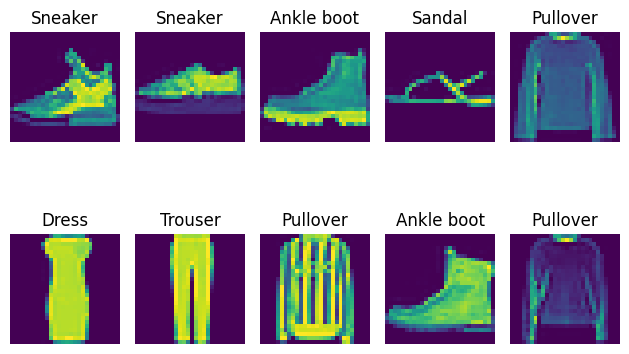

In [20]:
import matplotlib.pyplot as plt

LABELS = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

fig, axes = plt.subplots(2, 5)
for axis_idx, axis in enumerate(axes.flatten()):
    axis.set_title(LABELS[y_samples[axis_idx]])
    axis.imshow(X_samples[axis_idx])
    axis.axis('off')
fig.tight_layout()
fig.show()

### Loading and transforming our dataset

Now we know what our data looks like, let's load and transform it in a format suitable for training our model.

The images are transformed via the following 3-step process, which is all handled automatically with the `torchvision.transforms.ToTensor` transformation we saw earlier.

1. Resize all images to $28 \times 28$ pixels
1. Rescale all channels from integer in range $[0, 255]$ to float in range $[0, 1]$
1. Change the shape of each image from format `(height, width, channels)` to `(channels, height, width)`

Unlike MindSpore 2.8.0, PyTorch recommends we keep the labels as class indices without one-hot encoding for optimized computation of the [`torch.nn.CrossEntropyLoss`](https://docs.pytorch.org/docs/2.8/generated/torch.nn.CrossEntropyLoss.html) we'll see later.

In [21]:
train_data = datasets.FashionMNIST(root=data_dir,
                                   train=True,
                                   transform=transforms.ToTensor())
test_data = datasets.FashionMNIST(root=data_dir,
                                  train=False,
                                  transform=transforms.ToTensor())

For training, we'll split our data in batches of $2^9=512$ samples. For validation, we'll use a single batch of $10,000$ samples.

In [22]:
train_loader = DataLoader(train_data, batch_size=512, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10000, shuffle=True)

### Defining our neural network, optimizer, activation and loss functions

Here's the neural network we'll be using.

1. Flatten the images to $28 \times 28 \times 1 = 784$ features
1. 1st hidden layer with $784$ input channels and $2^{10}=1024$ output channels, ReLU activation
1. 1st dropout layer with $p = 0.3$
1. 2nd hidden layer with $1024$ input channels and $2^9=512$ output channels, ReLU activation
1. 2nd dropout layer with $p = 0.2$
1. Fully connected layer with $512$ input channels and $10$ output channels

We'll also copy our model to device memory using the `to` method. Confirm that our resulting model is in device memory by accessing its parameters with the `parameters` method which returns an iterator.

In [23]:
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 1024),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 10)
).to(gpu_0)
model, next(model.parameters()).device

(Sequential(
   (0): Flatten(start_dim=1, end_dim=-1)
   (1): Linear(in_features=784, out_features=1024, bias=True)
   (2): ReLU()
   (3): Dropout(p=0.3, inplace=False)
   (4): Linear(in_features=1024, out_features=512, bias=True)
   (5): ReLU()
   (6): Dropout(p=0.2, inplace=False)
   (7): Linear(in_features=512, out_features=10, bias=True)
 ),
 device(type='npu', index=0))

Use `torch.nn.CrossEntropyLoss` for our loss function. It combines softmax activation and cross-entropy loss under the hood using the [LogSumExp](https://en.wikipedia.org/wiki/LogSumExp) trick to prevent numerical underflow and overflow.

In [24]:
criterion = nn.CrossEntropyLoss()
criterion

CrossEntropyLoss()

For the optimizer, use [`torch.optim.SGD`](https://docs.pytorch.org/docs/2.8/generated/torch.optim.SGD.html) with the following hyperparameters.

1. Learning rate: `0.01`
1. Weight decay: `1e-3`
1. Momentum: `0.9`

In [25]:
import torch.optim as optim

optimizer = optim.SGD(params=model.parameters(), lr=0.01, weight_decay=1e-3, momentum=0.9)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0.001
)

With our neural network, combined activation + loss function, optimizer and hyperparameters defined, it's time to define our training loop.

### Training our neural network

Let's train our model over 20 epochs. We define the per-batch and per-epoch training logic as below.

In [26]:
def train_batch(X_batch, y_batch):
    optimizer.zero_grad()
    y_hat = model(X_batch)
    loss = criterion(y_hat, y_batch)
    loss.backward()
    optimizer.step()
    return loss.item()

def train_epoch(epoch=0):
    training_losses = []
    print(f'Epoch {epoch} start')
    model.train(True)
    batch_count = len(train_loader)
    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
        loss = train_batch(X_batch.to(gpu_0), y_batch.to(gpu_0))
        if batch_idx % 10 == 0:
            print(f'Training loss: {loss:.4f} [{batch_idx}/{batch_count}]')
        training_losses.append(loss)
    print(f'Epoch {epoch} end')
    return training_losses

Define our validation logic at the end of each epoch as well.

In [27]:
def validate_epoch(epoch=0):
    model.eval()
    validation_loss = None
    with torch.no_grad():
        X_test, y_test = next(iter(test_loader))
        y_hat = model(X_test.to(gpu_0))
        validation_loss = criterion(y_hat, y_test.to(gpu_0))
        validation_loss = validation_loss.item()
    print(f'Validation loss at epoch {epoch}: {validation_loss:.4f}')
    return validation_loss

Now train our model using the utility functions defined above.

In [28]:
epochs = 20

In [29]:
training_losses = []
validation_losses = []
for epoch in range(epochs):
    training_losses.extend(train_epoch(epoch=epoch))
    validation_losses.append(validate_epoch(epoch=epoch))
len(training_losses), len(validation_losses)

Epoch 0 start


/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/common/context/op_context.py:38: DeprecationWarning: currentThread() is deprecated, use current_thread() instead
  return _contexts.setdefault(threading.currentThread().ident, [])


..Training loss: 2.3067 [0/118]
Training loss: 2.2449 [10/118]
Training loss: 2.1330 [20/118]
Training loss: 1.9472 [30/118]
Training loss: 1.6020 [40/118]
Training loss: 1.3151 [50/118]
Training loss: 1.1242 [60/118]
Training loss: 0.9828 [70/118]
Training loss: 0.9193 [80/118]
Training loss: 0.9016 [90/118]
Training loss: 0.8678 [100/118]
Training loss: 0.8293 [110/118]
..Epoch 0 end
Validation loss at epoch 0: 0.7749
Epoch 1 start
Training loss: 0.7629 [0/118]
Training loss: 0.7416 [10/118]
Training loss: 0.7207 [20/118]
Training loss: 0.7641 [30/118]
Training loss: 0.7532 [40/118]
Training loss: 0.7241 [50/118]
Training loss: 0.7039 [60/118]
Training loss: 0.6603 [70/118]
Training loss: 0.7116 [80/118]
Training loss: 0.5626 [90/118]
Training loss: 0.6959 [100/118]
Training loss: 0.6535 [110/118]
Epoch 1 end
Validation loss at epoch 1: 0.6184
Epoch 2 start
Training loss: 0.7138 [0/118]
Training loss: 0.5561 [10/118]
Training loss: 0.5997 [20/118]
Training loss: 0.6026 [30/118]
Train

(2360, 20)

Plot the training and validation losses with Matplotlib.

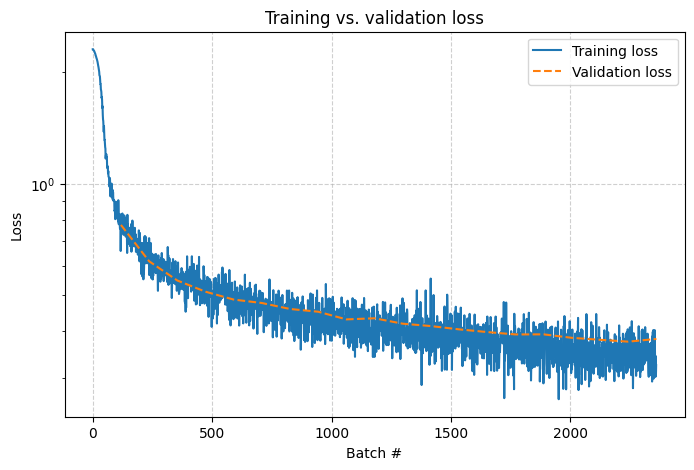

In [30]:
import numpy as np

batches_per_epoch = 118
batches_x = np.arange(batches_per_epoch * epochs)
training_losses_y = np.array(training_losses)
epochs_x = batches_per_epoch * np.arange(epochs) + batches_per_epoch
validation_losses_y = np.array(validation_losses)

plt.figure(figsize=(8, 5))

plt.plot(batches_x, training_losses_y, label='Training loss', linestyle='-')
plt.plot(epochs_x, validation_losses_y, label='Validation loss', linestyle='--')

plt.title('Training vs. validation loss')
plt.xlabel('Batch #')
plt.ylabel('Loss')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

### Validating the accuracy of our model

Let's compute the validation loss and accuracy of our trained model.

In [31]:
X_test = None
y_test = None

model.eval()
with torch.no_grad():
    X_test, y_test = next(iter(test_loader))
    y_hat = model(X_test.to(gpu_0))
    y_test = y_test.to(gpu_0)
    loss = criterion(y_hat, y_test).item()
    y_hat = torch.argmax(y_hat, dim=1)
    total = 10000
    correct = (y_hat == y_test).sum().item()
    accuracy = correct / total
    print(f'Loss: {loss:.4f}, Accuracy: {accuracy:.4f}')

.Loss: 0.3818, Accuracy: 0.8632


Our accuracy is around $85 \text{-} 90\%$, a noticeable improvement from our simple linear model. Not bad!

Let's see it in action - predict labels for 10 images from our validation set and compare the predictions to the actual labels.

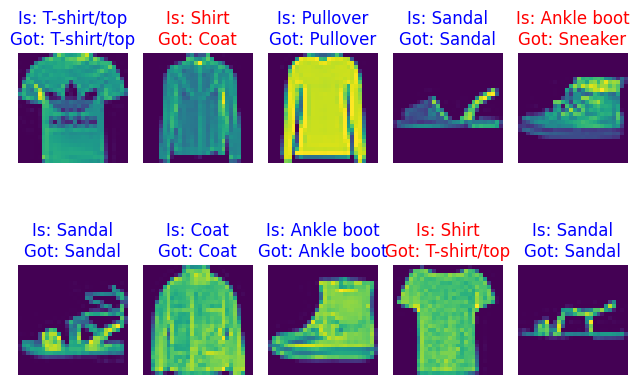

In [32]:
X_test_10, y_test_10 = X_test[:10], y_test[:10]
y_hat = model(X_test_10.to(gpu_0))
y_hat = torch.argmax(y_hat, dim=1)
X_test_10 = X_test_10.numpy()
y_hat = y_hat.cpu().numpy()
y_test_10 = y_test_10.cpu().numpy()

fig, axes = plt.subplots(2, 5)
for axis_idx, axis in enumerate(axes.flatten()):
    predicted = y_hat[axis_idx]
    actual = y_test_10[axis_idx]
    correct = (predicted == actual).item()
    color = 'blue' if correct else 'red'
    axis.set_title(f'Is: {LABELS[actual]}\nGot: {LABELS[predicted]}', color=color)
    axis.imshow(X_test_10[axis_idx].transpose(1, 2, 0))
    axis.axis('off')
fig.tight_layout()
fig.show()

### Exporting our model to ONNX format

With our model trained on the Fashion MNIST dataset with satisfactory accuracy, let's export it to ONNX format so others can download our model for inference. This is provided in PyTorch as [`torch.onnx.export`](https://docs.pytorch.org/docs/2.8/onnx_dynamo.html#torch.onnx.export).

In [33]:
import os

onnx_program = torch.onnx.export(model.cpu(), torch.from_numpy(X_test_10[:1]), dynamo=True)
onnx_program.save('fashion-mnist-mlp.onnx')
os.path.isfile('fashion-mnist-mlp.onnx')

W0501 10:54:44.200000 25893 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0501 10:54:44.203000 25893 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0501 10:54:44.207000 25893 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0501 10:54:44.213000 25893 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


True

## Concluding remarks and going further

We saw how the PyTorch Ascend plugin `torch-npu` allows us to migrate existing deep learning workloads originally optimized for NVIDIA GPUs to Huawei Ascend NPUs by simply adding an import statement to the existing code. While this approach may not work $100\%$ of the time especially if the code involves low-level performance optimizations tied to NVIDIA GPU hardware, it nonetheless greatly simplifies the migration path from NVIDIA to Ascend, allowing practitioners to focus on the interesting parts of the migration instead of being bogged down by repetitive grunt work.

Porting existing PyTorch deep learning workloads directly to Ascend is just the first step of the migration from NVIDIA's proprietary CUDA ecosystem to Huawei's open Ascend CANN ecosystem. To maximize the benefits of accelerating deep learning workloads on Ascend NPUs, a logical next step would be to port the entire codebase from PyTorch to the [MindSpore](https://www.mindspore.cn/) framework lead by Huawei and governed by the MindSpore community. Fortunately, MindSpore provides the [`mindspore.mint`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/mindspore.mint.html) API compatibility layer whose design and structure closely follows PyTorch's conventions. This enables practitioners already familiar with PyTorch to migrate their codebase to MindSpore without re-architecting their pipelines and workflows.

I hope you enjoyed following through this notebook experiment as much as I did authoring it and stay tuned for updates ;-\)